# **Dataset Overview**


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("Telco_customer_churn.csv")

In [13]:
df.head()
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

(7043, 33)

In [14]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


# **Data Cleaning**

In [15]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


In [16]:
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

In [61]:
df.dropna(subset=['Total Charges'], inplace=True)
if 'Churn Reason' in df.columns:
    df.drop('Churn Reason', axis=1, inplace=True)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.drop("CustomerID", axis=1, inplace=True)

In [20]:
df["churn"] = df["Churn Label"].map({"Yes":1, "No":0})

# **Exploratory Data Analysis (EDA)**

**Analyze Numerical Values (with Visualization)**

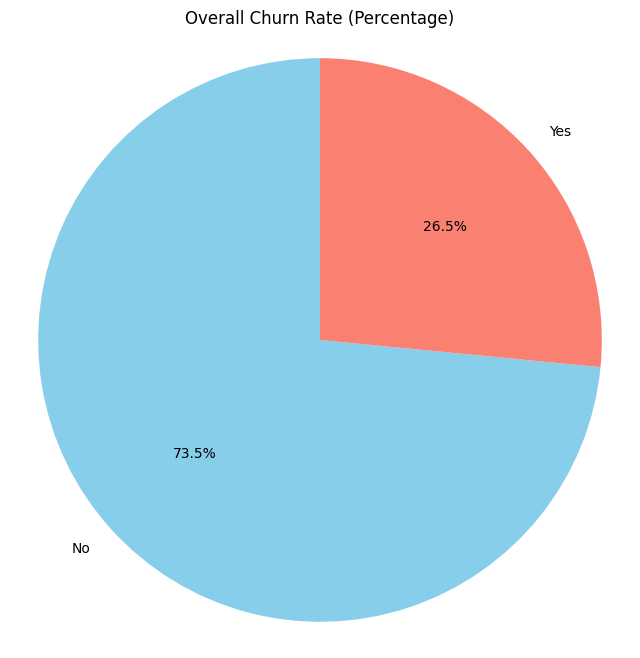

In [48]:
#Overall Churn Rate
churn_label_counts = df["Churn Label"].value_counts()
churn_label_counts

df_full_customer_base = pd.read_csv("Telco_customer_churn.csv")

churn_counts = df_full_customer_base['Churn Label'].value_counts()
churn_percentages = churn_counts / len(df_full_customer_base) * 100

plt.figure(figsize=(8, 8))
plt.pie(churn_percentages, labels=churn_percentages.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Overall Churn Rate (Percentage)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

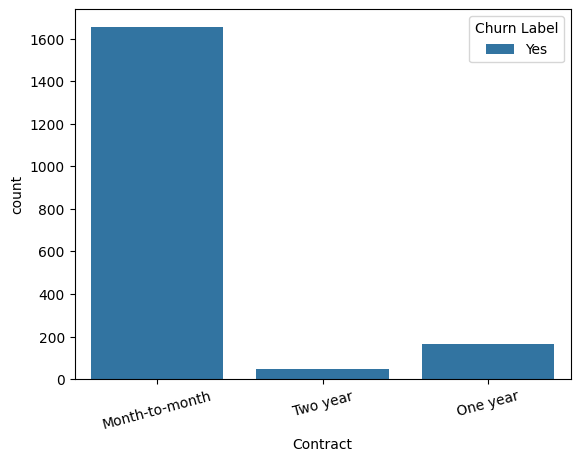

In [23]:
#Contract Type vs Churn
sns.countplot(x="Contract", hue="Churn Label", data=df)

plt.xticks(rotation=15)
plt.show()

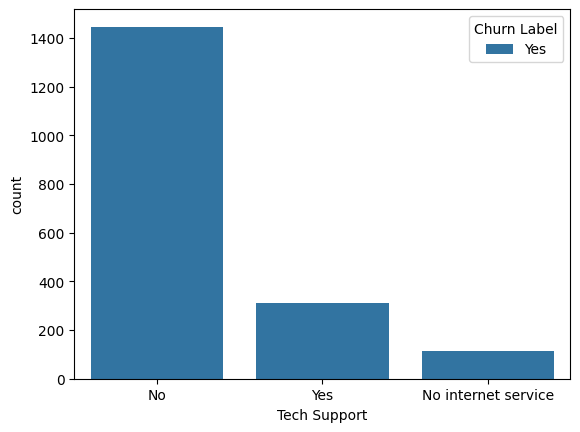

In [24]:
#Tech Support vs Churn
sns.countplot(x="Tech Support", hue="Churn Label", data=df)

plt.show()

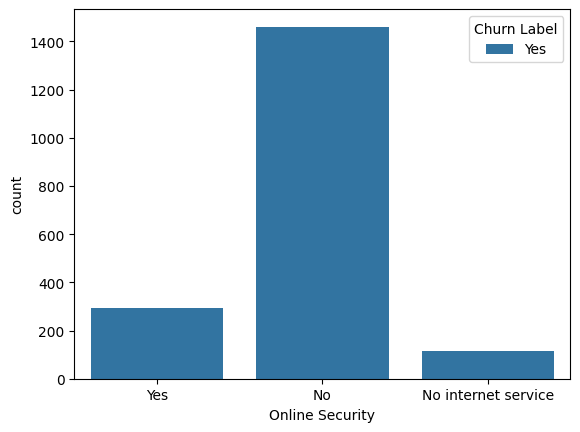

In [25]:
#Online Security vs Churn
sns.countplot(x="Online Security", hue="Churn Label", data=df)

plt.show()

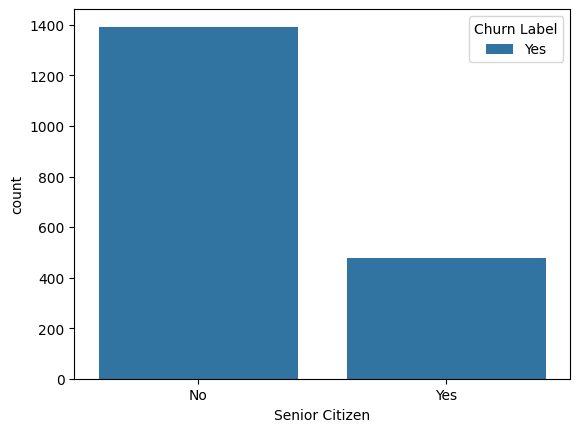

In [37]:
#Senior Citizen vs Churn
sns.countplot(x="Senior Citizen", hue="Churn Label", data=df)

plt.show()

**Analyze Categorical Values (with Visualization)**

In [49]:
#ContractType
pd.crosstab(df["Contract"], df["Churn Label"])

Churn Label,Yes
Contract,
Month-to-month,1655
One year,166
Two year,48


<Axes: xlabel='Payment Method', ylabel='count'>

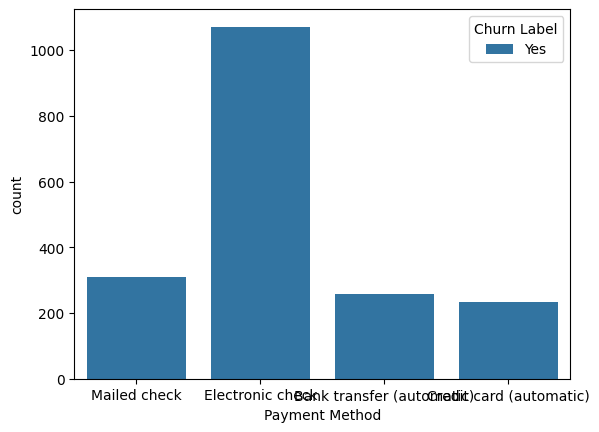

In [45]:
#PaymentMethod
pd.crosstab(df["Payment Method"], df["Churn Label"])
sns.countplot(x="Payment Method", hue="Churn Label", data=df)

<Axes: xlabel='Internet Service', ylabel='count'>

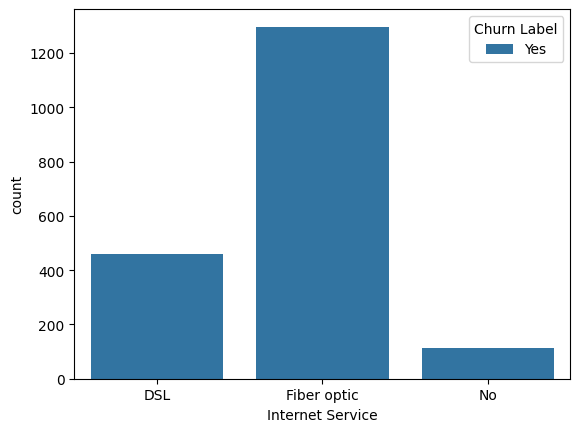

In [44]:
#InternetService
pd.crosstab(df["Internet Service"], df["Churn Label"])
sns.countplot(x="Internet Service", hue="Churn Label", data=df)


# **Predictive Modelling**

**Import and Data Loading**

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score, ConfusionMatrixDisplay
)

# Model persistence
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [73]:
# ── Load & replicate the cleaning steps from the EDA notebook ──────────────
df = pd.read_csv("Telco_customer_churn.csv")

df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.dropna(subset=["Total Charges"], inplace=True)

if "Churn Reason" in df.columns:
    df.drop("Churn Reason", axis=1, inplace=True)

df.drop_duplicates(inplace=True)
df.drop("CustomerID", axis=1, inplace=True)

# Binary target
df["churn"] = df["Churn Label"].map({"Yes": 1, "No": 0})

print(f"Dataset shape: {df.shape}")
print(f"Churn rate  : {df['churn'].mean():.2%}")

Dataset shape: (7032, 32)
Churn rate  : 26.58%


**Feature Engineering**

In [74]:
# ── Drop raw label columns that would leak the target ─────────────────────
COLS_TO_DROP = ["Churn Label", "Churn Score", "CLTV", "Churn Value"]
df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns], inplace=True)

# ── Derived features ───────────────────────────────────────────────────────
# Revenue per month relative to tenure
df["avg_monthly_revenue"] = df["Total Charges"] / (df["Tenure Months"].replace(0, 1))

# Service bundle count (proxy for customer stickiness)
service_cols = ["Phone Service", "Multiple Lines", "Online Security",
                "Online Backup", "Device Protection", "Tech Support",
                "Streaming TV", "Streaming Movies"]
df["service_count"] = df[service_cols].apply(
    lambda row: (row == "Yes").sum(), axis=1
)

# Short-tenure flag
df["short_tenure"] = (df["Tenure Months"] <= 12).astype(int)

print("Engineered features added.")
df[["avg_monthly_revenue", "service_count", "short_tenure"]].describe()

Engineered features added.


,avg_monthly_revenue,service_count,short_tenure
count,7032.000000,7032.000000,7032.000000
mean,64.799424,3.363339,0.309300
std,30.185891,2.062067,0.462238
min,13.775000,0.000000,0.000000
25%,36.179891,1.000000,0.000000
50%,70.373239,3.000000,0.000000
75%,90.179560,5.000000,1.000000
max,121.400000,8.000000,1.000000


**Preprocessing Pipeline**

In [75]:
TARGET = "churn"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identify column types
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features  ({len(num_cols)}): {num_cols}")
print(f"Categorical features ({len(cat_cols)}): {cat_cols}")

Numerical features  (10): ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'avg_monthly_revenue', 'service_count', 'short_tenure']
Categorical features (20): ['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


**Model Training**

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Perform train-test split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Define the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ])

# ── Helper: build an imblearn pipeline ────────────────────────────────────
def make_pipeline(classifier):
    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote",        SMOTE(random_state=42)),
        ("classifier",   classifier),
    ])

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=1000, C=0.5, random_state=42)
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(n_estimators=200, max_depth=10,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    ),
    "XGBoost": make_pipeline(
        XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      eval_metric="logloss", random_state=42, n_jobs=-1)
    ),
}

# ── Cross-validated ROC-AUC on training set ────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<25}  CV ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression        CV ROC-AUC: 0.8443 ± 0.0089
Random Forest              CV ROC-AUC: 0.8413 ± 0.0104
XGBoost                    CV ROC-AUC: 0.8626 ± 0.0081


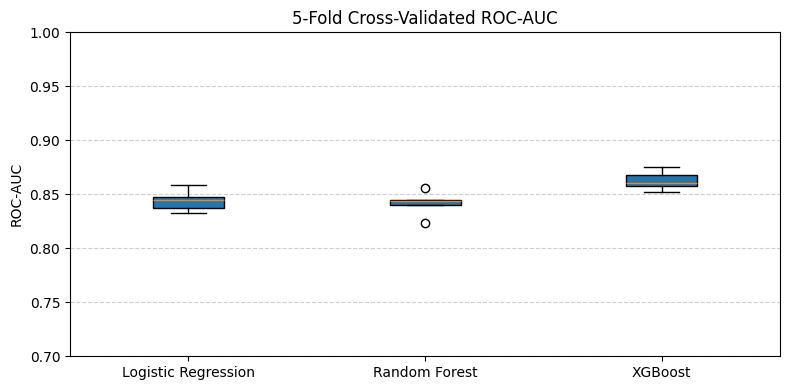

In [78]:
# ── Visualise cross-validation scores ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
ax.set_title("5-Fold Cross-Validated ROC-AUC")
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.7, 1.0)
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [79]:
# ── Fit all models on full training set ───────────────────────────────────
fitted = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"✓ {name} fitted.")

✓ Logistic Regression fitted.
✓ Random Forest fitted.
✓ XGBoost fitted.


**Evaluation on Hold-Out Test Set**


  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1033
       Churn       0.52      0.74      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.75      0.76      1407

  ROC-AUC : 0.8277


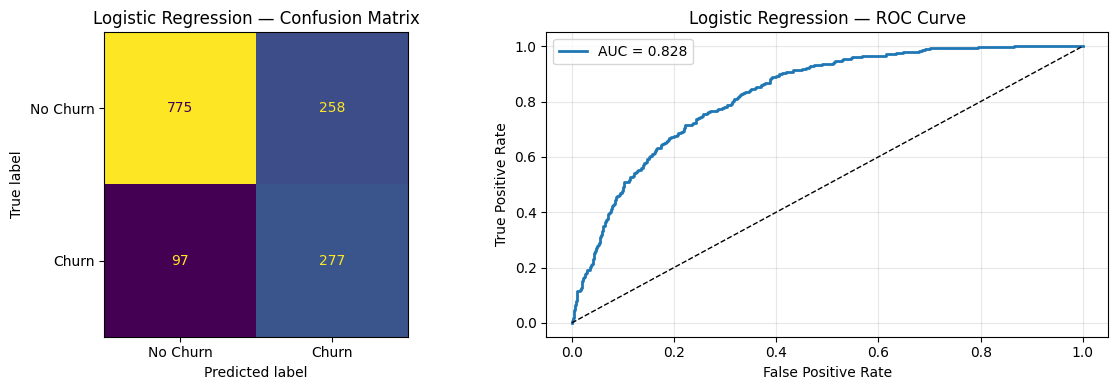


  Random Forest
              precision    recall  f1-score   support

    No Churn       0.90      0.76      0.82      1033
       Churn       0.53      0.76      0.63       374

    accuracy                           0.76      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.76      0.77      1407

  ROC-AUC : 0.8307


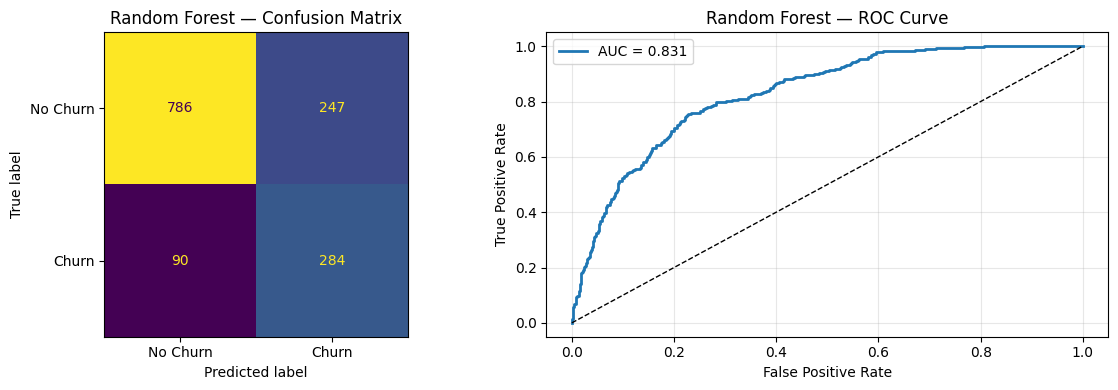


  XGBoost
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1033
       Churn       0.61      0.60      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407

  ROC-AUC : 0.8471


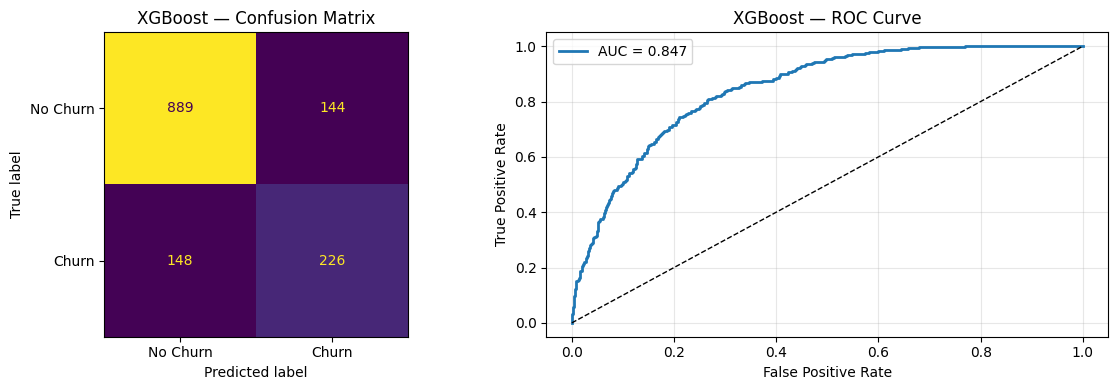

In [80]:
def evaluate(name, pipe, X_test, y_test):
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
    print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["No Churn", "Churn"],
        colorbar=False, ax=axes[0]
    )
    axes[0].set_title(f"{name} — Confusion Matrix")

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", lw=2)
    axes[1].plot([0, 1], [0, 1], "k--", lw=1)
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].set_title(f"{name} — ROC Curve")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return {"name": name, "auc": auc, "f1": f1_score(y_test, y_pred),
            "proba": y_proba}

results = {}
for name, pipe in fitted.items():
    results[name] = evaluate(name, pipe, X_test, y_test)

**ROC Curve Comparison**

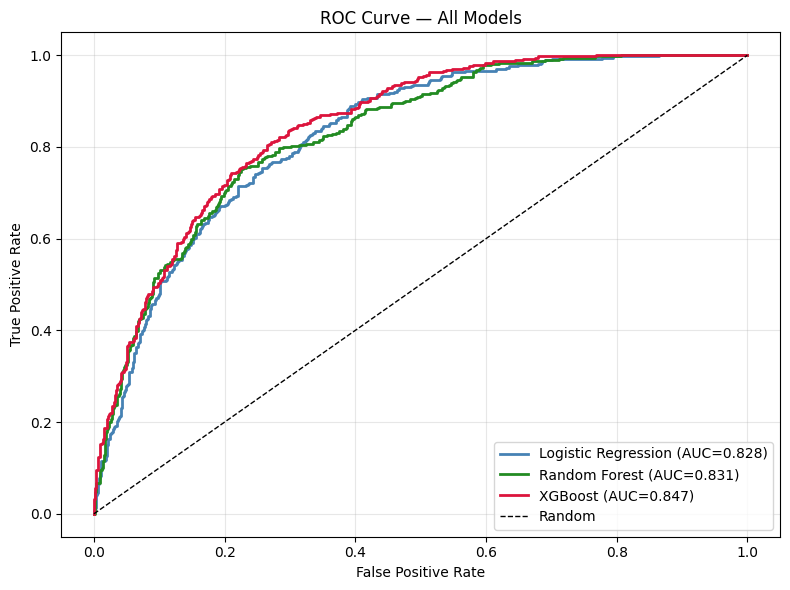

In [81]:
plt.figure(figsize=(8, 6))
colors = ["steelblue", "forestgreen", "crimson"]
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res["proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Feature Importance**

Best model: XGBoost  (AUC = 0.8471)


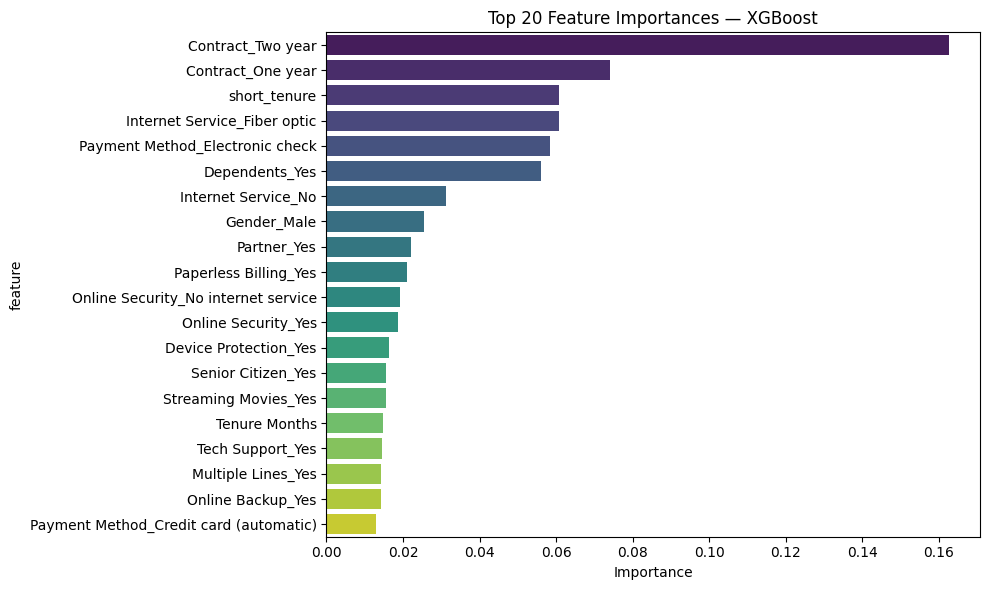

                               feature  importance
                     Contract_Two year    0.162608
                     Contract_One year    0.074143
                          short_tenure    0.060746
          Internet Service_Fiber optic    0.060746
       Payment Method_Electronic check    0.058356
                        Dependents_Yes    0.055967
                   Internet Service_No    0.031364
                           Gender_Male    0.025416
                           Partner_Yes    0.022210
                 Paperless Billing_Yes    0.020937
   Online Security_No internet service    0.019236
                   Online Security_Yes    0.018831
                 Device Protection_Yes    0.016429
                    Senior Citizen_Yes    0.015664
                  Streaming Movies_Yes    0.015620
                         Tenure Months    0.014702
                      Tech Support_Yes    0.014563
                    Multiple Lines_Yes    0.014324
                     Online Bac

In [83]:
# ── Pick best model by AUC ────────────────────────────────────────────────
best_name = max(results, key=lambda k: results[k]["auc"])
best_pipe = fitted[best_name]
print(f"Best model: {best_name}  (AUC = {results[best_name]['auc']:.4f})")

# ── Extract feature names after OHE ──────────────────────────────────────
ohe_feature_names = (
    best_pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

clf = best_pipe.named_steps["classifier"]

if hasattr(clf, "feature_importances_"):          # tree-based models
    importances = clf.feature_importances_
elif hasattr(clf, "coef_"):                        # linear models
    importances = np.abs(clf.coef_[0])
else:
    importances = None

if importances is not None:
    feat_df = pd.DataFrame({
        "feature":    all_feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x="importance", y="feature", data=feat_df, palette="viridis")
    plt.title(f"Top 20 Feature Importances — {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(feat_df.to_string(index=False))

**Threshold Tuning**

Default threshold is 0.5, but for churn use-cases it's often better to optimise for **F1-score** (or recall, if reducing false negatives is prioritised).

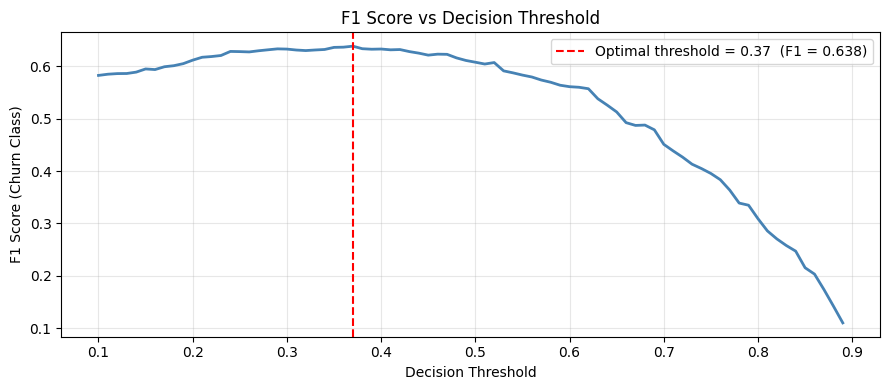


Optimal threshold : 0.37
Classification report at optimal threshold:
              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1033
       Churn       0.56      0.74      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.76      0.74      1407
weighted avg       0.81      0.78      0.79      1407



In [84]:
best_proba = results[best_name]["proba"]

thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_test, (best_proba >= t).astype(int)) for t in thresholds]

optimal_threshold = thresholds[np.argmax(f1_scores)]
optimal_f1        = max(f1_scores)

plt.figure(figsize=(9, 4))
plt.plot(thresholds, f1_scores, lw=2, color="steelblue")
plt.axvline(optimal_threshold, color="red", linestyle="--",
            label=f"Optimal threshold = {optimal_threshold:.2f}  (F1 = {optimal_f1:.3f})")
plt.xlabel("Decision Threshold")
plt.ylabel("F1 Score (Churn Class)")
plt.title("F1 Score vs Decision Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold : {optimal_threshold:.2f}")
print(f"Classification report at optimal threshold:")
y_pred_opt = (best_proba >= optimal_threshold).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=["No Churn", "Churn"]))

**Precision-Recall Curve**

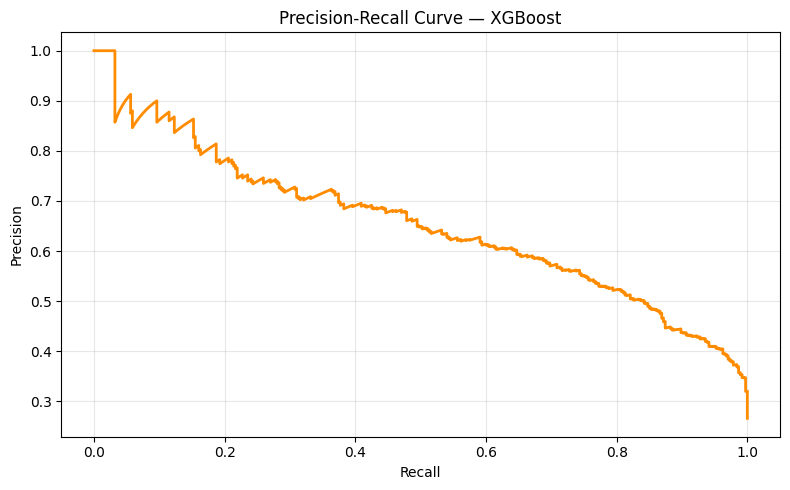

In [85]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, best_proba)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, lw=2, color="darkorange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve — {best_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Save Best Model**

In [86]:
model_path = "churn_best_model.joblib"
joblib.dump(best_pipe, model_path)
print(f"Model saved to '{model_path}'")

# ── Quick inference demo ───────────────────────────────────────────────────
loaded_model = joblib.load(model_path)
sample       = X_test.iloc[:5].copy()
sample_proba = loaded_model.predict_proba(sample)[:, 1]

print("\nSample predictions on 5 test records:")
for i, prob in enumerate(sample_proba):
    label = "Churn" if prob >= optimal_threshold else "No Churn"
    print(f"  Customer {i+1}: churn probability = {prob:.3f}  →  {label}")

Model saved to 'churn_best_model.joblib'

Sample predictions on 5 test records:
  Customer 1: churn probability = 0.025  →  No Churn
  Customer 2: churn probability = 0.679  →  Churn
  Customer 3: churn probability = 0.021  →  No Churn
  Customer 4: churn probability = 0.229  →  No Churn
  Customer 5: churn probability = 0.232  →  No Churn
